In [45]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Customer Churn Prediction

## Import Libraries

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv("Churn_Modelling.csv")

## Understanding the data

In [6]:
df.head()
#It is a bank customer data. 
#Here we predict that customer exicted the bank or not.
#Tenure denoted how many year ago customer join bank.
#EstimatedSalary is a salary of customer per year

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [8]:
print(df.shape)

(10000, 14)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.duplicated().sum()

0

In [11]:
df['Exited'].value_counts()

0    7963
1    2037
Name: Exited, dtype: int64

In [12]:
df['Gender'].value_counts()

Male      5457
Female    4543
Name: Gender, dtype: int64

In [13]:
df['Geography'].value_counts()

France     5014
Germany    2509
Spain      2477
Name: Geography, dtype: int64

## Cleaning And transforming data

In [14]:
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

In [15]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [16]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [17]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)
#This dummies function describe three columns into two columns in binary form.
#Ex. If Geography_Germany & Geography_Spain both are 0 then customer from France.
#Ex. Gender_male --> 0 then Customer is female.

In [18]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [19]:
X = df.drop(columns=['Exited'])
y = df['Exited']

## Model Building

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2,  random_state=1)

In [21]:
X_train.shape, X_test.shape

((8000, 11), (2000, 11))

In [22]:
y_train.shape, y_test.shape

((8000,), (2000,))

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [24]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [25]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [26]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [27]:
model = Sequential()

model.add(Dense(10, activation='relu', input_dim = 11))
model.add(Dense(7, activation='relu'))
model.add(Dense(1, activation= 'sigmoid'))

C:\Users\manth\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │            77 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205 (820.00 B)

 Trainable params: 205 (820.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(loss='binary_crossentropy', optimizer= 'Adam', metrics=['accuracy'])

In [30]:
history = model.fit(X_train_scaled, y_train, epochs= 100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6069 - loss: 0.6544 - val_accuracy: 0.7975 - val_loss: 0.5087
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - accuracy: 0.7955 - loss: 0.4835 - val_accuracy: 0.7975 - val_loss: 0.4708
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - accuracy: 0.8031 - loss: 0.4442 - val_accuracy: 0.7987 - val_loss: 0.4470
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - accuracy: 0.7945 - loss: 0.4425 - val_accuracy: 0.8037 - val_loss: 0.4299
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.8164 - loss: 0.4117 - val_accuracy: 0.8175 - val_loss: 0.4105
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 744us/step - accuracy: 0.8226 - loss: 0.4045 - val_accuracy: 0.8231 - val_loss: 0.3956
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.8373 - loss: 0.3839 - val_accuracy: 0.8256 - val_loss: 0.3852
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - accuracy: 0.8414 - loss: 0.3

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - accuracy: 0.8650 - loss: 0.3272 - val_accuracy: 0.8512 - val_loss: 0.3478
Epoch 51/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.8655 - loss: 0.3258 - val_accuracy: 0.8512 - val_loss: 0.3468
Epoch 52/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - accuracy: 0.8671 - loss: 0.3248 - val_accuracy: 0.8494 - val_loss: 0.3472
Epoch 53/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - accuracy: 0.8565 - loss: 0.3359 - val_accuracy: 0.8487 - val_loss: 0.3481
Epoch 54/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - accuracy: 0.8586 - loss: 0.3412 - val_accuracy: 0.8456 - val_loss: 0.3476
Epoch 55/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - accuracy: 0.8611 - loss: 0.3304 - val_accuracy: 0.8512 - val_loss: 0.3475
Epoch 56/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - accuracy: 0.8726 - loss: 0.3212 - val_accuracy: 0.8550 - val_loss: 0.3471
Epoch 57/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step - accuracy: 0.8707 - loss: 0.3244

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - accuracy: 0.8685 - loss: 0.3164 - val_accuracy: 0.8512 - val_loss: 0.3503
Epoch 100/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - accuracy: 0.8655 - loss: 0.3264 - val_accuracy: 0.8469 - val_loss: 0.3492


In [31]:
model.layers[0].get_weights()

[array([[ 0.3174568 , -0.03249595,  0.27217567,  0.26262215, -0.29811174,
         -0.06352121, -0.18002452,  0.12992807,  0.0976971 ,  0.1275835 ],
        [-0.0356508 , -0.23670313, -0.06870411, -0.07851918,  0.4202398 ,
         -0.49077553,  0.23059519,  0.27626437, -1.2429754 , -0.8085776 ],
        [ 0.21854304, -0.06029973,  0.02823242, -0.30937696,  0.44072837,
          0.10811708, -0.15000822, -0.03225147,  0.16334245, -0.309508  ],
        [ 0.284247  , -0.4732546 , -0.68570685,  0.08501133, -0.3848014 ,
         -0.0087282 , -0.20162134,  0.07436121,  0.12345314,  0.05314771],
        [ 0.8423003 , -0.936254  , -0.30606344,  1.1523799 , -0.04647967,
          0.7020002 ,  1.2722218 , -0.15411532, -0.4381261 ,  0.06067685],
        [-0.6983658 , -0.3022367 , -0.11614892, -0.03128363, -0.57685196,
          0.7440142 ,  0.14427052,  0.07381303, -0.14808147, -0.02915884],
        [-0.04512954, -0.31634736,  0.05535273,  0.02213564,  0.4029022 ,
          0.17998959, -0.4897233

In [32]:
history.history

{'accuracy': [0.7134374976158142,
  0.7971875071525574,
  0.7979687452316284,
  0.8037499785423279,
  0.8168749809265137,
  0.831250011920929,
  0.8374999761581421,
  0.8426562547683716,
  0.8426562547683716,
  0.84375,
  0.8450000286102295,
  0.8460937738418579,
  0.8475000262260437,
  0.8465625047683716,
  0.8475000262260437,
  0.8482812643051147,
  0.8489062786102295,
  0.8482812643051147,
  0.8496875166893005,
  0.850781261920929,
  0.8510937690734863,
  0.852343738079071,
  0.8532812595367432,
  0.8529687523841858,
  0.8548437356948853,
  0.8550000190734863,
  0.8548437356948853,
  0.8567187786102295,
  0.8551562428474426,
  0.8564062714576721,
  0.8582812547683716,
  0.8578125238418579,
  0.858593761920929,
  0.8589062690734863,
  0.859375,
  0.8600000143051147,
  0.8606250286102295,
  0.8590624928474426,
  0.8606250286102295,
  0.8615624904632568,
  0.8615624904632568,
  0.8620312213897705,
  0.8623437285423279,
  0.8620312213897705,
  0.8612499833106995,
  0.8607812523841858,
 

In [35]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step


In [36]:
y_pred = np.where(y_log>0.5, 1 ,0)

In [37]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)*100

86.25

## Accuracy & Loss Visualization 

In [38]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'loss')

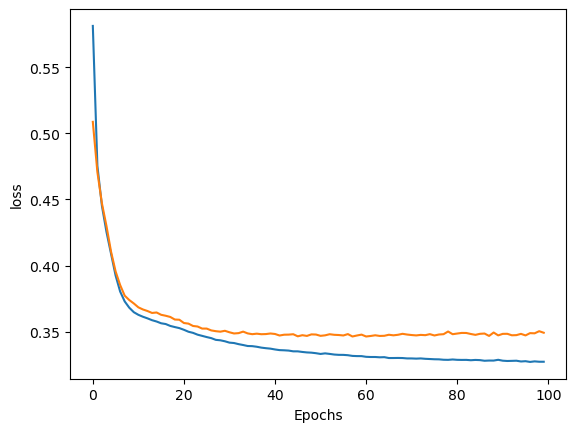

In [44]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("loss")

Text(0, 0.5, 'Accuracy')

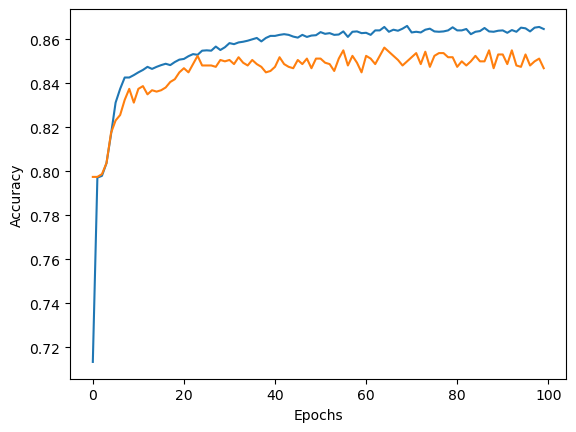

In [45]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")